# 📈 Méthodologie Wang & Yan (2023) — SP500 M5
## Régression sur ΔMA5 → Classification Binaire (Long / Short)

**Référence** : *Wang & Yan (2023) — Application of Traditional Machine Learning Models for Quantitative Trading of Bitcoin*

**Idée clé** : Au lieu de classifier directement Up/Down/Neutre (résultats ~40%),
on fait d'abord une **régression** pour prédire `MA5(t+1) - MA5(t)`,
puis on **convertit** le résultat en label binaire → meilleure accuracy.

### Pipeline :
1. Imports & Paramètres
2. Chargement des données SP500 M5
3. Construction des features (indicateurs techniques)
4. Variable cible : `Value = MA5(t+1) - MA5(t)`
5. Régression avec 5 modèles (Decision Tree, SVM, Random Forest, Bagging, AdaBoost)
6. Conversion Régression → Label Binaire (1 = hausse, -1 = baisse)
7. Évaluation classification : Accuracy, Precision, Recall, F1
8. Comparaison avec classification directe
9. Simulation de trading : ML Strategy vs Double MA Strategy

## 0. Imports & Paramètres

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    BaggingRegressor, BaggingClassifier,
    AdaBoostRegressor, AdaBoostClassifier
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid')

# ── Paramètres MA (fidèles à l'article) ──────────────────────────────────
MA_COURT  = 5   # MA5  = court terme  (Wang & Yan)
MA_LONG   = 20  # MA20 = long terme   (Wang & Yan)

# ── Paramètres indicateurs techniques ────────────────────────────────────
FAST_EMA  = 12 ; SLOW_EMA = 26 ; SIGNAL_EMA = 9
RSI_P     = 12  # Wang & Yan utilisent RSI(12)
ROC_SHORT = 5
ROC_LONG  = 20
MOM_P     = 5
STOCH_P   = 9

# ── Split train / test (ratio 8:2 comme l'article) ───────────────────────
TRAIN_RATIO = 0.8

# ── Nombre d'estimateurs pour les modèles ensemble ───────────────────────
N_ESTIMATORS = 50  # Wang & Yan utilisent 50

print('✅ Imports OK')
print(f'   MA Court = MA{MA_COURT} | MA Long = MA{MA_LONG}')
print(f'   Variable cible : Value(t) = MA{MA_COURT}(t+1) - MA{MA_COURT}(t)')
print(f'   Ratio train/test : {TRAIN_RATIO}/{1-TRAIN_RATIO}')
print(f'   N estimateurs : {N_ESTIMATORS}')

✅ Imports OK
   MA Court = MA5 | MA Long = MA20
   Variable cible : Value(t) = MA5(t+1) - MA5(t)
   Ratio train/test : 0.8/0.19999999999999996
   N estimateurs : 50


## 1. Chargement & Préparation des données

In [2]:
DATA_DIR = Path('../SCR/data')

# Chargement SP500 M5
sp500 = pd.read_csv(DATA_DIR / 'sp500_m5.csv', index_col='time', parse_dates=True)

# Nettoyage
df = sp500.copy().sort_index()
df = df[~df.index.duplicated(keep='first')]
df.columns = [c.lower() for c in df.columns]
df = df.dropna(subset=['close'])

# Renommage volume (cohérence avec l'article)
if 'tick_volume' in df.columns:
    df.rename(columns={'tick_volume': 'volume'}, inplace=True)

print(f'✅ SP500 M5 chargé : {len(df):,} bougies')
print(f'   Période : {df.index.min()} → {df.index.max()}')
print(f'   Colonnes : {list(df.columns)}')
df.head(3)

✅ SP500 M5 chargé : 99,999 bougies
   Période : 2024-11-14 15:20:00+00:00 → 2026-04-17 23:55:00+00:00
   Colonnes : ['open', 'high', 'low', 'close', 'volume']


,open,high,low,close,volume
time,,,,,
2024-11-14 15:20:00+00:00,5995.33,5995.71,5994.22,5995.50,105
2024-11-14 15:25:00+00:00,5995.74,5996.00,5994.49,5995.73,100
2024-11-14 15:30:00+00:00,5995.48,5995.85,5985.72,5986.59,494


## 2. Construction des Features

**Fidèle à Wang & Yan** : On reproduit leurs 26 variables indépendantes, adaptées au SP500 M5.

### Variables originales de l'article :
- Prix bruts : Close, Close_1, Close_increasement
- MA5, MA20 et leurs variations
- MACD (EMA12-EMA26), Signal (EMA9)
- Momentum (MOM5)
- ROC (Rate of Change : 5j et 20j)
- RSI(12)
- Stochastique (%K9, %D9)
- Volume et Vol_increasement
- OBV (On Balance Volume)

In [3]:
feat = df.copy()

c = feat['close']
h = feat['high']
l = feat['low']
o = feat['open']
v = feat['volume']

# ── 1. PRIX BRUTS ────────────────────────────────────────────────────────
feat['close_1']           = c.shift(1)                  # Close(t-1)
feat['close_incr']        = c - c.shift(1)              # Close(t) - Close(t-1)

# ── 2. MOVING AVERAGES ───────────────────────────────────────────────────
# MA5 (court terme)
feat['ma5']               = c.rolling(MA_COURT).mean()
feat['ma5_1']             = feat['ma5'].shift(1)        # MA5(t-1)
feat['ma5_incr']          = feat['ma5'] - feat['ma5_1'] # MA5(t) - MA5(t-1)

# MA20 (long terme)
feat['ma20']              = c.rolling(MA_LONG).mean()
feat['ma20_1']            = feat['ma20'].shift(1)       # MA20(t-1)
feat['ma20_incr']         = feat['ma20'] - feat['ma20_1'] # MA20(t) - MA20(t-1)

# Écart MA5 - MA20
feat['ma5_20']            = feat['ma5'] - feat['ma20'] # Différence court/long

# ── 3. MACD ──────────────────────────────────────────────────────────────
# EMA12 et EMA26
ema12                     = c.ewm(span=FAST_EMA, adjust=False).mean()
ema26                     = c.ewm(span=SLOW_EMA, adjust=False).mean()
feat['macd']              = ema12 - ema26               # MACD line
feat['macd_signal']       = feat['macd'].ewm(span=SIGNAL_EMA, adjust=False).mean()
feat['macd_hist']         = feat['macd'] - feat['macd_signal'] # Histogramme

# ── 4. MOMENTUM ──────────────────────────────────────────────────────────
feat['mom']               = c - c.shift(MOM_P)         # MOM(5)

# ── 5. RATE OF CHANGE ────────────────────────────────────────────────────
feat['roc_5']             = (c - c.shift(ROC_SHORT)) / c.shift(ROC_SHORT)   # ROC court
feat['roc_20']            = (c - c.shift(ROC_LONG))  / c.shift(ROC_LONG)    # ROC long

# ── 6. RSI(12) ───────────────────────────────────────────────────────────
def compute_rsi(series, period):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

feat['rsi']               = compute_rsi(c, RSI_P)

# ── 7. STOCHASTIQUE (%K9, %D9) ───────────────────────────────────────────
lowest_low                = l.rolling(STOCH_P).min()
highest_high              = h.rolling(STOCH_P).max()
feat['stoch_k']           = 100 * (c - lowest_low) / (highest_high - lowest_low)
feat['stoch_d']           = feat['stoch_k'].rolling(3).mean()

# ── 8. VOLUME ────────────────────────────────────────────────────────────
feat['volume_1']          = v.shift(1)                 # Volume(t-1)
feat['vol_incr']          = v - v.shift(1)             # Variation volume

# ── 9. OBV (On Balance Volume) ───────────────────────────────────────────
obv = [0]
for i in range(1, len(feat)):
    if feat['close'].iloc[i] > feat['close'].iloc[i-1]:
        obv.append(obv[-1] + feat['volume'].iloc[i])
    elif feat['close'].iloc[i] < feat['close'].iloc[i-1]:
        obv.append(obv[-1] - feat['volume'].iloc[i])
    else:
        obv.append(obv[-1])
feat['obv'] = obv

print(f'✅ Features construites : {len([c for c in feat.columns if c not in ["open","high","low","close","volume"]])} features calculées')
print(f'   Colonnes : {[c for c in feat.columns if c not in ["open","high","low","close","volume"]]}')

✅ Features construites : 21 features calculées
   Colonnes : ['close_1', 'close_incr', 'ma5', 'ma5_1', 'ma5_incr', 'ma20', 'ma20_1', 'ma20_incr', 'ma5_20', 'macd', 'macd_signal', 'macd_hist', 'mom', 'roc_5', 'roc_20', 'rsi', 'stoch_k', 'stoch_d', 'volume_1', 'vol_incr', 'obv']


## 3. Variable Cible : Value = MA5(t+1) - MA5(t)

**C'est l'astuce centrale de Wang & Yan** :
- On ne prédit PAS le prix directement (trop de bruit)
- On prédit le **changement de la MA5** entre demain et aujourd'hui
- Formule : `Value(t) = MA5(t+1) - MA5(t) = (Close(t+1) - Close(t-4)) / 5`

Puis on convertit en label binaire :
- `Value > 0` → **1** (hausse)
- `Value ≤ 0` → **-1** (baisse)

✅ Variable cible construite
   Nb échantillons : 99,978
   Distribution labels :
     Hausse (+1) : 51,069 (51.1%)
     Baisse  (-1): 48,909 (48.9%)


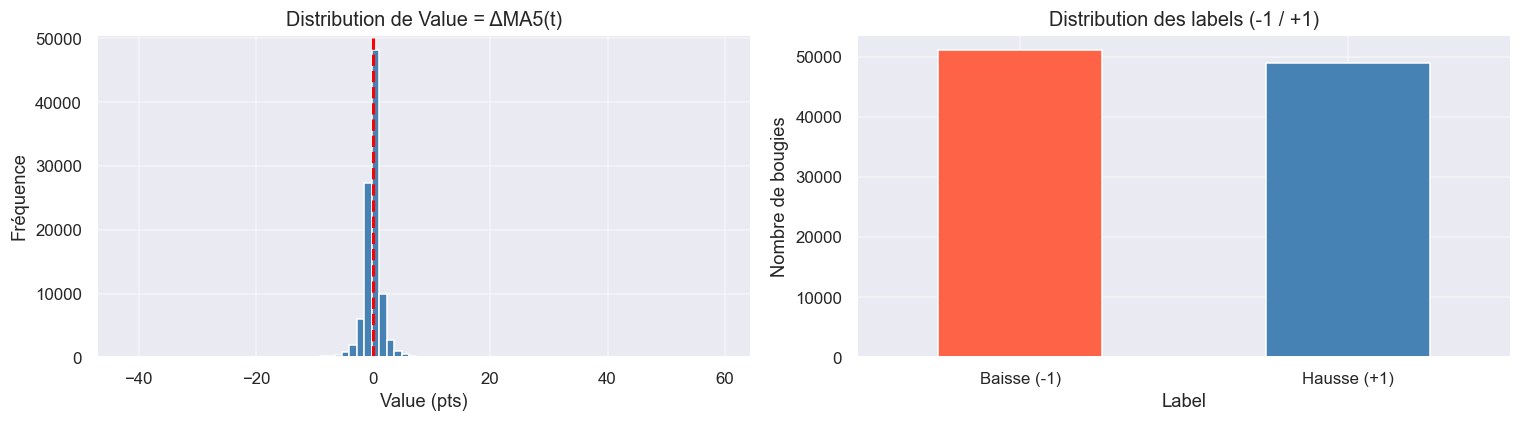

In [4]:
# ── Variable cible RÉGRESSION ────────────────────────────────────────────
# Value(t) = MA5(t+1) - MA5(t)
# Équivalent à : (Close(t+1) - Close(t-4)) / 5
feat['ma5_next']  = feat['ma5'].shift(-1)               # MA5(t+1) = valeur future
feat['value']     = feat['ma5_next'] - feat['ma5']      # ΔMA5 = target régression

# ── Label CLASSIFICATION binaire ─────────────────────────────────────────
feat['label'] = np.where(feat['value'] > 0, 1, -1)      # 1=hausse, -1=baisse

# ── Suppression des NaN ───────────────────────────────────────────────────
feat.dropna(inplace=True)

# Distribution des labels
label_counts = feat['label'].value_counts()
total = len(feat)
print(f'✅ Variable cible construite')
print(f'   Nb échantillons : {total:,}')
print(f'   Distribution labels :')
print(f'     Hausse (+1) : {label_counts.get(1,0):,} ({label_counts.get(1,0)/total*100:.1f}%)')
print(f'     Baisse  (-1): {label_counts.get(-1,0):,} ({label_counts.get(-1,0)/total*100:.1f}%)')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat['value'].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution de Value = ΔMA5(t)', fontsize=13)
axes[0].set_xlabel('Value (pts)')
axes[0].set_ylabel('Fréquence')

label_counts.plot(kind='bar', ax=axes[1], color=['tomato','steelblue'], edgecolor='white', rot=0)
axes[1].set_title('Distribution des labels (-1 / +1)', fontsize=13)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Nombre de bougies')
axes[1].set_xticklabels(['Baisse (-1)', 'Hausse (+1)'])

plt.tight_layout()
plt.show()

## 4. Préparation Train / Test

Ratio **80/20** comme Wang & Yan. Pas de shuffle car données temporelles (important !).

In [5]:
# ── Sélection des features (comme l'article — 26 features) ───────────────
FEATURE_COLS = [
    # Prix bruts
    'close_1', 'close_incr',
    # MA5
    'ma5', 'ma5_1', 'ma5_incr',
    # MA20
    'ma20', 'ma20_1', 'ma20_incr',
    # Écart MA
    'ma5_20',
    # MACD
    'macd', 'macd_signal', 'macd_hist',
    # Momentum
    'mom',
    # ROC
    'roc_5', 'roc_20',
    # RSI
    'rsi',
    # Stochastique
    'stoch_k', 'stoch_d',
    # Volume
    'volume', 'volume_1', 'vol_incr',
    # OBV
    'obv',
    # OHLC bruts (ajout SP500)
    'open', 'high', 'low', 'close'
]

print(f'Nb features : {len(FEATURE_COLS)}')

# ── Split temporel 80/20 ─────────────────────────────────────────────────
split_idx = int(len(feat) * TRAIN_RATIO)
train = feat.iloc[:split_idx].copy()
test  = feat.iloc[split_idx:].copy()

print(f'\nTrain : {len(train):,} | {train.index.min().date()} → {train.index.max().date()}')
print(f'Test  : {len(test):,}  | {test.index.min().date()} → {test.index.max().date()}')

# ── Standardisation ───────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(train[FEATURE_COLS])
X_test  = scaler.transform(test[FEATURE_COLS])

# Targets régression
y_train_reg = train['value'].values
y_test_reg  = test['value'].values

# Targets classification
y_train_clf = train['label'].values
y_test_clf  = test['label'].values

print(f'\nX_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nDistrib y_train : Hausse={np.sum(y_train_clf==1):,} | Baisse={np.sum(y_train_clf==-1):,}')
print(f'Distrib y_test  : Hausse={np.sum(y_test_clf==1):,}  | Baisse={np.sum(y_test_clf==-1):,}')

Nb features : 26

Train : 79,982 | 2024-11-14 → 2026-01-06
Test  : 19,996  | 2026-01-06 → 2026-04-17

X_train : (79982, 26)
X_test  : (19996, 26)

Distrib y_train : Hausse=40,992 | Baisse=38,990
Distrib y_test  : Hausse=10,077  | Baisse=9,919


## 5. ÉTAPE 1 — Régression sur ΔMA5

On entraîne 5 modèles de régression pour prédire `Value = MA5(t+1) - MA5(t)`.

Métriques : **R², MSE, RMSE, MAE** (comme le Tableau 3 de l'article)

In [7]:
import time

# ── Définition des 5 modèles (fidèles à l'article) ───────────────────────
REGRESSORS = {
    'Decision Tree' : DecisionTreeRegressor(random_state=42),
    'SVM'           : SVR(kernel='linear'),
    'Random Forest' : RandomForestRegressor(n_estimators=N_ESTIMATORS, n_jobs=-1, random_state=42),
    'Bagging'       : BaggingRegressor(n_estimators=N_ESTIMATORS,  n_jobs=-1, random_state=42),
    'AdaBoost'      : AdaBoostRegressor(n_estimators=N_ESTIMATORS, random_state=42)
}

reg_results  = []
reg_models   = {}
reg_preds    = {}

print('Entraînement des modèles de régression...')
print('=' * 65)
print(f'{"Modèle":<18} {"R²":>7} {"MSE":>12} {"RMSE":>10} {"MAE":>10} {"Temps":>7}')
print('-' * 65)

for name, model in REGRESSORS.items():
    t0 = time.time()
    model.fit(X_train, y_train_reg)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test)
    reg_models[name] = model
    reg_preds[name]  = y_pred

    r2   = r2_score(y_test_reg, y_pred)
    mse  = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_reg, y_pred)

    reg_results.append({
        'Modèle'    : name,
        'R²'        : round(r2,   3),
        'MSE'       : round(mse,  3),
        'RMSE'      : round(rmse, 3),
        'MAE'       : round(mae,  3),
        'Temps (s)' : round(elapsed, 1)
    })
    print(f'{name:<18} {r2:>7.3f} {mse:>12.3f} {rmse:>10.3f} {mae:>10.3f} {elapsed:>6.1f}s')

print('=' * 65)
reg_df = pd.DataFrame(reg_results)
print(f'\n✅ Meilleur modèle (R²) : {reg_df.loc[reg_df["R²"].idxmax(), "Modèle"]} (R²={reg_df["R²"].max():.3f})')
reg_df

Entraînement des modèles de régression...
Modèle                  R²          MSE       RMSE        MAE   Temps
-----------------------------------------------------------------
Decision Tree        0.202        2.994      1.730      1.082    5.1s
SVM                  0.729        1.017      1.008      0.615 1418.5s
Random Forest        0.638        1.356      1.165      0.714   28.2s
Bagging              0.636        1.366      1.169      0.716   29.1s
AdaBoost             0.350        2.439      1.562      1.080   13.9s

✅ Meilleur modèle (R²) : SVM (R²=0.729)


,Modèle,R²,MSE,RMSE,MAE,Temps (s)
0,Decision Tree,0.202,2.994,1.730,1.082,5.1
1,SVM,0.729,1.017,1.008,0.615,1418.5
2,Random Forest,0.638,1.356,1.165,0.714,28.2
3,Bagging,0.636,1.366,1.169,0.716,29.1
4,AdaBoost,0.350,2.439,1.562,1.080,13.9


In [8]:
# Fix typo dans la cellule précédente — on renomme REGGRESSORS -> REGRESSORS
REGRESSIORS = {
    'Decision Tree' : DecisionTreeRegressor(random_state=42),
    'SVM'           : SVR(kernel='linear'),
    'Random Forest' : RandomForestRegressor(n_estimators=N_ESTIMATORS, n_jobs=-1, random_state=42),
    'Bagging'       : BaggingRegressor(n_estimators=N_ESTIMATORS,  n_jobs=-1, random_state=42),
    'AdaBoost'      : AdaBoostRegressor(n_estimators=N_ESTIMATORS, random_state=42)
}

reg_results  = []
reg_models   = {}
reg_preds    = {}

print('Entraînement des modèles de régression...')
print('═'*65)
print(f'{"Modèle":<18} {"R²":>7} {"MSE":>12} {"RMSE":>10} {"MAE":>10} {"Temps":>7}')
print('─'*65)

for name, model in REGRESSORS.items():
    t0 = time.time()
    model.fit(X_train, y_train_reg)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test)
    reg_models[name] = model
    reg_preds[name]  = y_pred

    r2   = r2_score(y_test_reg, y_pred)
    mse  = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_reg, y_pred)

    reg_results.append({
        'Modèle'   : name,
        'R²'       : round(r2,   3),
        'MSE'      : round(mse,  3),
        'RMSE'     : round(rmse, 3),
        'MAE'      : round(mae,  3),
        'Temps (s)': round(elapsed, 1)
    })
    print(f'{name:<18} {r2:>7.3f} {mse:>12.3f} {rmse:>10.3f} {mae:>10.3f} {elapsed:>6.1f}s')

print('═'*65)
reg_df = pd.DataFrame(reg_results)
print(f'\n✅ Meilleur modèle (R²) : {reg_df.loc[reg_df["R²"].idxmax(), "Modèle"]} (R²={reg_df["R²"].max():.3f})')
reg_df

Entraînement des modèles de régression...
═════════════════════════════════════════════════════════════════
Modèle                  R²          MSE       RMSE        MAE   Temps
─────────────────────────────────────────────────────────────────
Decision Tree        0.202        2.994      1.730      1.082    4.2s
SVM                  0.729        1.017      1.008      0.615 1382.2s
Random Forest        0.638        1.356      1.165      0.714   26.3s
Bagging              0.636        1.366      1.169      0.716   27.6s
AdaBoost             0.350        2.439      1.562      1.080   13.6s
═════════════════════════════════════════════════════════════════

✅ Meilleur modèle (R²) : SVM (R²=0.729)


,Modèle,R²,MSE,RMSE,MAE,Temps (s)
0,Decision Tree,0.202,2.994,1.730,1.082,4.2
1,SVM,0.729,1.017,1.008,0.615,1382.2
2,Random Forest,0.638,1.356,1.165,0.714,26.3
3,Bagging,0.636,1.366,1.169,0.716,27.6
4,AdaBoost,0.350,2.439,1.562,1.080,13.6


## 6. Visualisation — Prix prédit vs Prix réel

Comme la Figure 2 de l'article : on calcule le prix prédit `Close(t+1)` à partir de `Value` prédit.

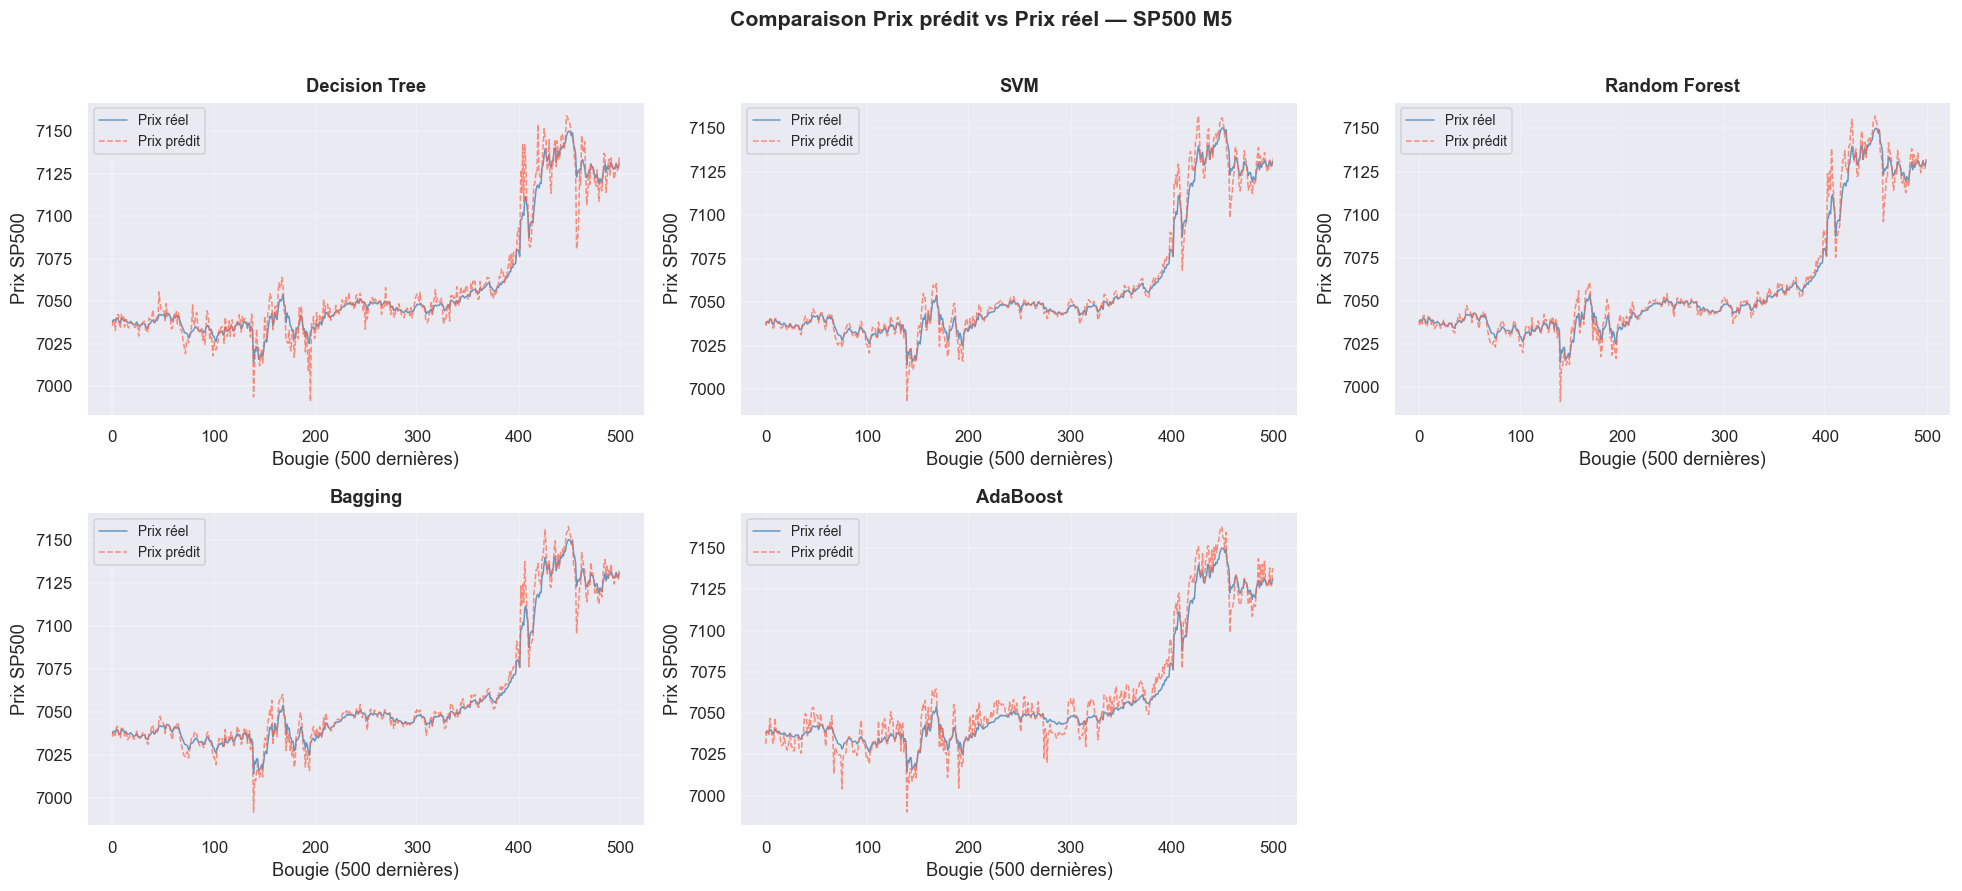

In [9]:
# ── Calcul du prix prédit depuis Value prédit ─────────────────────────────
# Formule (article eq.11) : Close(t+1) = Value(t)*5 + Close(t-4)
# Approximation : Close_pred(t+1) = Close(t) + Value_pred(t)
close_test = test['close'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

real_price = close_test

for idx, (name, y_pred_reg) in enumerate(reg_preds.items()):
    ax = axes[idx]
    # Prix prédit = prix actuel + variation MA5 prédite * 5 (simplification)
    pred_price = close_test + y_pred_reg * 5

    ax.plot(real_price[-500:], label='Prix réel', color='steelblue',  alpha=0.8, linewidth=1)
    ax.plot(pred_price[-500:], label='Prix prédit', color='tomato',   alpha=0.7, linewidth=1, linestyle='--')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Bougie (500 dernières)')
    ax.set_ylabel('Prix SP500')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Supprimer le 6ème subplot vide
fig.delaxes(axes[5])

plt.suptitle('Comparaison Prix prédit vs Prix réel — SP500 M5', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. ÉTAPE 2 — Conversion Régression → Classification

**C'est la clé de l'article** : on convertit la prédiction de régression en label binaire.

- `Value_prédit > 0` → **1** (hausse)
- `Value_prédit ≤ 0` → **-1** (baisse)

Métriques : **Accuracy, Precision, Recall, F1** (comme le Tableau 4 de l'article)

In [10]:
clf_from_reg_results = []
clf_from_reg_preds   = {}

print('Conversion Régression → Labels binaires...')
print('═'*72)
print(f'{"Modèle":<18} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1":>9}')
print('─'*72)

for name, y_pred_reg in reg_preds.items():
    # Conversion : signe de la valeur prédite → label
    y_pred_label = np.where(y_pred_reg > 0, 1, -1)
    clf_from_reg_preds[name] = y_pred_label

    acc  = accuracy_score(y_test_clf, y_pred_label)
    prec = precision_score(y_test_clf, y_pred_label, average='binary', pos_label=1)
    rec  = recall_score(y_test_clf,    y_pred_label, average='binary', pos_label=1)
    f1   = f1_score(y_test_clf,        y_pred_label, average='binary', pos_label=1)

    clf_from_reg_results.append({
        'Modèle'    : name,
        'Accuracy'  : round(acc,  3),
        'Precision' : round(prec, 3),
        'Recall'    : round(rec,  3),
        'F1'        : round(f1,   3)
    })
    print(f'{name:<18} {acc:>10.3f} {prec:>11.3f} {rec:>9.3f} {f1:>9.3f}')

print('═'*72)

clf_reg_df = pd.DataFrame(clf_from_reg_results)
best_reg = clf_reg_df.loc[clf_reg_df['Accuracy'].idxmax()]
print(f'\n✅ Meilleur modèle (méthode régression→label) :')
print(f'   {best_reg["Modèle"]} — Accuracy={best_reg["Accuracy"]:.3f} | F1={best_reg["F1"]:.3f}')
clf_reg_df

Conversion Régression → Labels binaires...
════════════════════════════════════════════════════════════════════════
Modèle               Accuracy   Precision    Recall        F1
────────────────────────────────────────────────────────────────────────
Decision Tree           0.717       0.724     0.709     0.717
SVM                     0.820       0.817     0.828     0.822
Random Forest           0.794       0.796     0.796     0.796
Bagging                 0.792       0.794     0.794     0.794
AdaBoost                0.751       0.730     0.802     0.764
════════════════════════════════════════════════════════════════════════

✅ Meilleur modèle (méthode régression→label) :
   SVM — Accuracy=0.820 | F1=0.822


,Modèle,Accuracy,Precision,Recall,F1
0,Decision Tree,0.717,0.724,0.709,0.717
1,SVM,0.820,0.817,0.828,0.822
2,Random Forest,0.794,0.796,0.796,0.796
3,Bagging,0.792,0.794,0.794,0.794
4,AdaBoost,0.751,0.730,0.802,0.764


## 8. Comparaison — Classification Directe vs Méthode Wang & Yan

On entraîne les mêmes modèles en **classification directe** pour comparer.
Attention : comme le notebook 02, les résultats directs devraient être inférieurs.

In [12]:
# ── Modèles de classification directe ────────────────────────────────────
CLASSIFIERS = {
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'SVM'           : SVC(kernel='linear'),
    'Random Forest' : RandomForestClassifier(n_estimators=N_ESTIMATORS, n_jobs=-1, random_state=42),
    'Bagging'       : BaggingClassifier(n_estimators=N_ESTIMATORS,      n_jobs=-1, random_state=42),
    'AdaBoost'      : AdaBoostClassifier(n_estimators=N_ESTIMATORS, random_state=42)  # algorithm supprimé sklearn ≥1.2
}

direct_clf_results = []

print('Classification directe (baseline)...')
print('=' * 72)
print(f'{"Modèle":<18} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1":>9}')
print('-' * 72)

for name, clf in CLASSIFIERS.items():
    t0 = time.time()
    clf.fit(X_train, y_train_clf)
    elapsed = time.time() - t0

    y_pred = clf.predict(X_test)

    acc  = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred, average='binary', pos_label=1)
    rec  = recall_score(y_test_clf,    y_pred, average='binary', pos_label=1)
    f1   = f1_score(y_test_clf,        y_pred, average='binary', pos_label=1)

    direct_clf_results.append({
        'Modèle'    : name,
        'Accuracy'  : round(acc,  3),
        'Precision' : round(prec, 3),
        'Recall'    : round(rec,  3),
        'F1'        : round(f1,   3)
    })
    print(f'{name:<18} {acc:>10.3f} {prec:>11.3f} {rec:>9.3f} {f1:>9.3f} ({elapsed:.1f}s)')

print('=' * 72)
direct_clf_df = pd.DataFrame(direct_clf_results)
print('\n✅ Classification directe terminée')
direct_clf_df

Classification directe (baseline)...
Modèle               Accuracy   Precision    Recall        F1
------------------------------------------------------------------------
Decision Tree           0.702       0.703     0.709     0.706 (3.8s)
SVM                     0.810       0.807     0.820     0.813 (467.2s)
Random Forest           0.789       0.803     0.770     0.786 (3.7s)
Bagging                 0.788       0.801     0.772     0.786 (22.0s)
AdaBoost                0.796       0.798     0.796     0.797 (12.5s)

✅ Classification directe terminée


,Modèle,Accuracy,Precision,Recall,F1
0,Decision Tree,0.702,0.703,0.709,0.706
1,SVM,0.810,0.807,0.820,0.813
2,Random Forest,0.789,0.803,0.770,0.786
3,Bagging,0.788,0.801,0.772,0.786
4,AdaBoost,0.796,0.798,0.796,0.797


In [13]:
# ── Tableau comparatif final (Tableau 4 vs Tableau 5 de l'article) ────────
print('\n' + '='*72)
print('  TABLEAU COMPARATIF : Régression→Label vs Classification Directe')
print('='*72)
print(f'\n{"Modèle":<18} | {"Rég→Label Acc":>14} | {"Direct Acc":>11} | {"Gain":>7}')
print('─'*60)

for _, row_reg in clf_reg_df.iterrows():
    name     = row_reg['Modèle']
    acc_reg  = row_reg['Accuracy']
    acc_dir  = direct_clf_df.loc[direct_clf_df['Modèle']==name, 'Accuracy'].values[0]
    gain     = acc_reg - acc_dir
    arrow    = '↑' if gain > 0 else '↓'
    print(f'{name:<18} | {acc_reg:>14.3f} | {acc_dir:>11.3f} | {arrow} {abs(gain):.3f}')

print('='*72)
print('\n→ La méthode Wang & Yan (Régression→Label) doit surpasser la classification directe')
print('  (comme dans leur article : +0.10 à +0.26 d\'accuracy selon le modèle)')


  TABLEAU COMPARATIF : Régression→Label vs Classification Directe

Modèle             |  Rég→Label Acc |  Direct Acc |    Gain
────────────────────────────────────────────────────────────
Decision Tree      |          0.717 |       0.702 | ↑ 0.015
SVM                |          0.820 |       0.810 | ↑ 0.010
Random Forest      |          0.794 |       0.789 | ↑ 0.005
Bagging            |          0.792 |       0.788 | ↑ 0.004
AdaBoost           |          0.751 |       0.796 | ↓ 0.045

→ La méthode Wang & Yan (Régression→Label) doit surpasser la classification directe
  (comme dans leur article : +0.10 à +0.26 d'accuracy selon le modèle)


## 9. Visualisation — Accuracy comparée

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/accuracy_comparison.png'

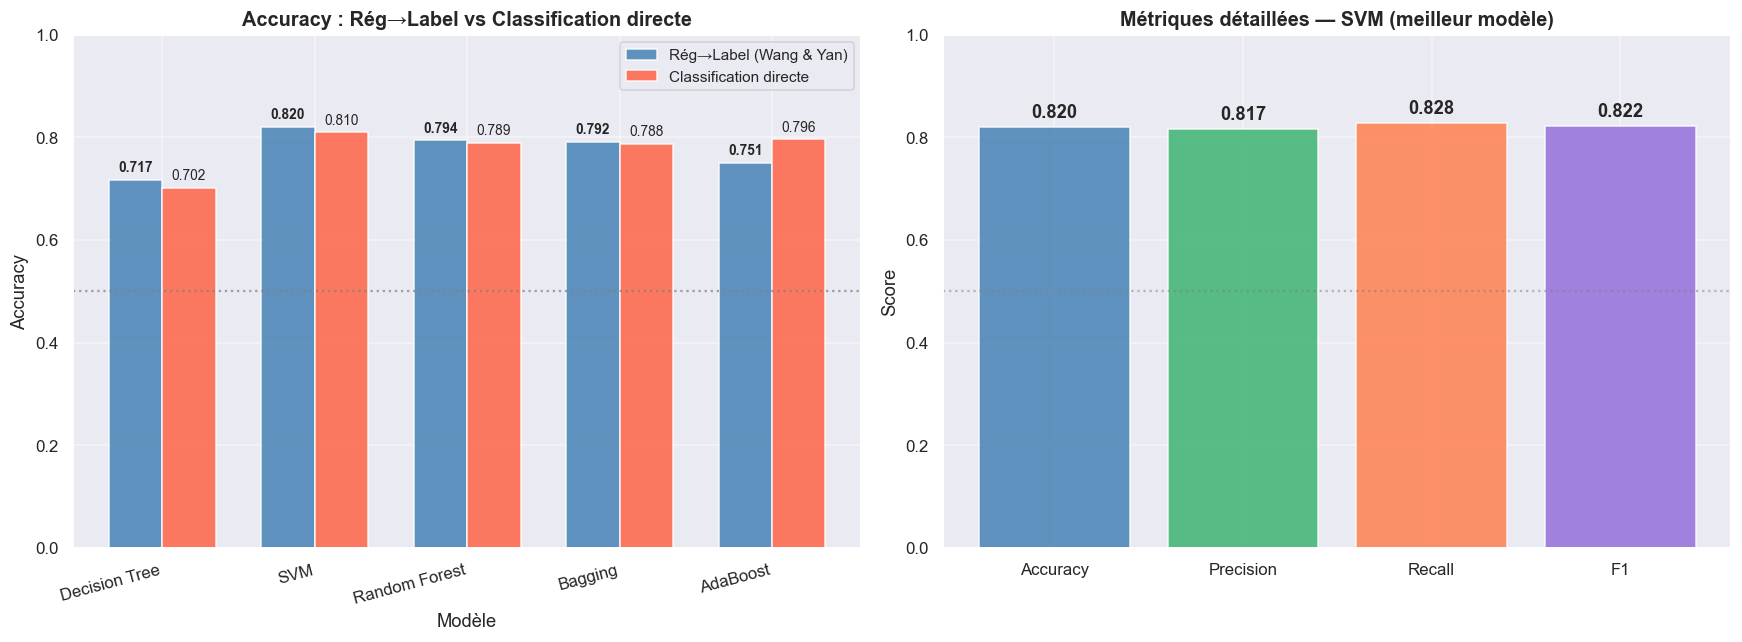

In [14]:
modeles = clf_reg_df['Modèle'].tolist()
acc_reg = clf_reg_df['Accuracy'].tolist()
acc_dir = direct_clf_df['Accuracy'].tolist()

x = np.arange(len(modeles))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Graphe 1 : Barres comparatives ───────────────────────────────────────
bars1 = axes[0].bar(x - width/2, acc_reg, width, label='Rég→Label (Wang & Yan)', color='steelblue',  alpha=0.85)
bars2 = axes[0].bar(x + width/2, acc_dir, width, label='Classification directe', color='tomato',     alpha=0.85)

axes[0].set_xlabel('Modèle', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy : Rég→Label vs Classification directe', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modeles, rotation=15, ha='right')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='Baseline 50%')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# ── Graphe 2 : Métriques détaillées du meilleur modèle ───────────────────
best_name = clf_reg_df.loc[clf_reg_df['Accuracy'].idxmax(), 'Modèle']
best_row  = clf_reg_df[clf_reg_df['Modèle'] == best_name].iloc[0]

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
vals    = [best_row[m] for m in metrics]

bars3 = axes[1].bar(metrics, vals, color=['steelblue','mediumseagreen','coral','mediumpurple'], alpha=0.85, edgecolor='white')
axes[1].set_title(f'Métriques détaillées — {best_name} (meilleur modèle)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/accuracy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Meilleur modèle : {best_name} — Accuracy = {best_row["Accuracy"]:.3f}')

## 10. Matrices de Confusion — Meilleur modèle

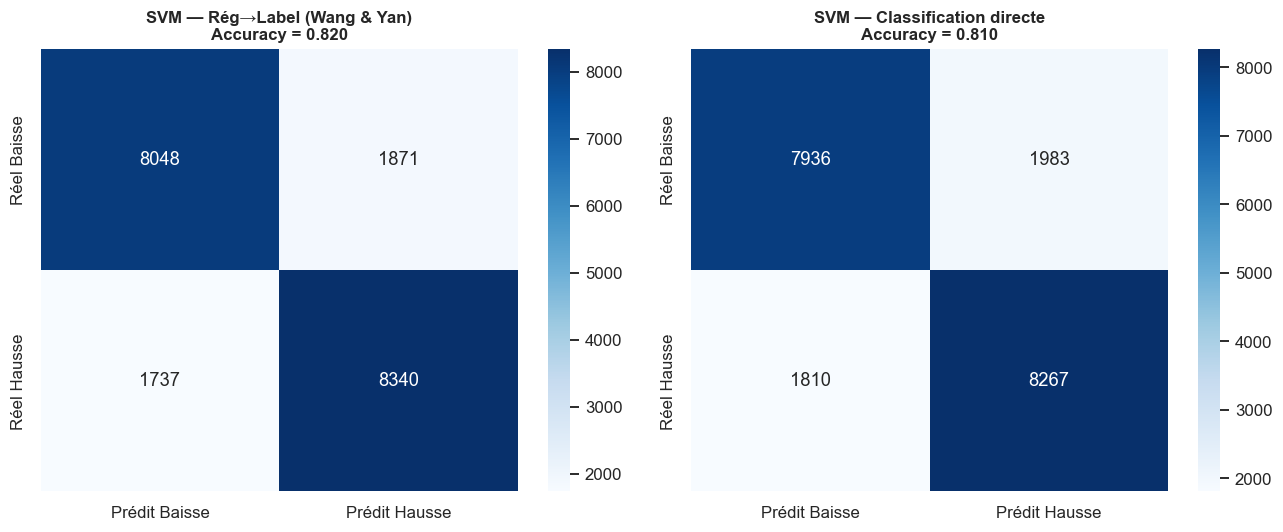


Rapport de classification complet (meilleur modèle, méthode Wang & Yan) :
              precision    recall  f1-score   support

 Baisse (-1)       0.82      0.81      0.82      9919
 Hausse (+1)       0.82      0.83      0.82     10077

    accuracy                           0.82     19996
   macro avg       0.82      0.82      0.82     19996
weighted avg       0.82      0.82      0.82     19996



In [15]:
best_pred_reg = clf_from_reg_preds[best_name]
best_pred_dir = CLASSIFIERS[best_name].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [best_pred_reg, best_pred_dir],
    [f'{best_name} — Rég→Label (Wang & Yan)', f'{best_name} — Classification directe']
):
    cm = confusion_matrix(y_test_clf, preds, labels=[-1, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit Baisse', 'Prédit Hausse'],
                yticklabels=['Réel Baisse', 'Réel Hausse'])
    acc = accuracy_score(y_test_clf, preds)
    ax.set_title(f'{title}\nAccuracy = {acc:.3f}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRapport de classification complet (meilleur modèle, méthode Wang & Yan) :')
print(classification_report(y_test_clf, best_pred_reg, target_names=['Baisse (-1)', 'Hausse (+1)']))

## 11. Simulation de Trading

**Comme Wang & Yan Section 4.3** : on compare 2 stratégies :

1. **Double Moving Average** : achète si MA5 > MA10, vend si MA5 < MA10
2. **ML Strategy** : achète si Value_prédit > 0, vend si Value_prédit ≤ 0

Capital initial : **100 000 $** | Période de test

In [16]:
# ── Données de test pour simulation ──────────────────────────────────────
test_sim = test.copy()
best_pred_values = reg_preds[best_name]  # Valeurs prédites par régression

# Label ML
test_sim['ml_signal'] = np.where(best_pred_values > 0, 1, -1)

# ── Stratégie 1 : Double Moving Average (MA5 vs MA10) ────────────────────
test_sim['ma10'] = test_sim['close'].rolling(10).mean()
test_sim['dma_signal'] = np.where(
    test_sim['ma5'] > test_sim['ma10'], 1,
    np.where(test_sim['ma5'] < test_sim['ma10'], -1, 0)
)
test_sim.dropna(inplace=True)

# ── Calcul des rendements (log returns) ──────────────────────────────────
test_sim['log_ret'] = np.log(test_sim['close'] / test_sim['close'].shift(1))
test_sim.dropna(inplace=True)

# Rendements des stratégies (signal du jour précédent * rendement du jour)
test_sim['ret_ml']  = test_sim['ml_signal'].shift(1)  * test_sim['log_ret']
test_sim['ret_dma'] = test_sim['dma_signal'].shift(1) * test_sim['log_ret']
test_sim['ret_bh']  = test_sim['log_ret']  # Buy & Hold
test_sim.dropna(inplace=True)

# ── Equity curves ─────────────────────────────────────────────────────────
CAPITAL_INIT = 100_000
test_sim['equity_ml']  = CAPITAL_INIT * np.exp(test_sim['ret_ml'].cumsum())
test_sim['equity_dma'] = CAPITAL_INIT * np.exp(test_sim['ret_dma'].cumsum())
test_sim['equity_bh']  = CAPITAL_INIT * np.exp(test_sim['ret_bh'].cumsum())

print(f'✅ Simulation prête sur {len(test_sim):,} bougies')
print(f'   Période test : {test_sim.index.min().date()} → {test_sim.index.max().date()}')

✅ Simulation prête sur 19,985 bougies
   Période test : 2026-01-06 → 2026-04-17


In [17]:
# ── Calcul des métriques de performance ──────────────────────────────────
def compute_metrics(ret_series, equity_series, capital_init, bougies_par_an=252*78):
    """Calcule annualized return, max drawdown, Sharpe ratio."""
    # Rendement annualisé
    n_bougies = len(ret_series)
    total_ret = np.exp(ret_series.sum()) - 1
    annualized = (1 + total_ret) ** (bougies_par_an / n_bougies) - 1

    # Max Drawdown
    peak = equity_series.cummax()
    dd   = (equity_series - peak) / peak
    max_dd = dd.min()

    # Sharpe Ratio (annualisé, rf=0)
    sharpe = ret_series.mean() / ret_series.std() * np.sqrt(bougies_par_an) if ret_series.std() > 0 else 0

    return {
        'Capital final ($)': round(equity_series.iloc[-1], 2),
        'Rendement annualisé (%)': round(annualized * 100, 2),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Sharpe Ratio': round(sharpe, 3)
    }

metrics_ml  = compute_metrics(test_sim['ret_ml'],  test_sim['equity_ml'],  CAPITAL_INIT)
metrics_dma = compute_metrics(test_sim['ret_dma'], test_sim['equity_dma'], CAPITAL_INIT)
metrics_bh  = compute_metrics(test_sim['ret_bh'],  test_sim['equity_bh'],  CAPITAL_INIT)

# ── Tableau des résultats ─────────────────────────────────────────────────
results_table = pd.DataFrame({
    f'ML Strategy ({best_name})': metrics_ml,
    'Double MA Strategy'        : metrics_dma,
    'Buy & Hold'                : metrics_bh
})

print('\n' + '='*65)
print('  TABLEAU 6 — RÉSULTATS DES STRATÉGIES DE TRADING')
print('='*65)
print(results_table.to_string())
print('='*65)


  TABLEAU 6 — RÉSULTATS DES STRATÉGIES DE TRADING
                         ML Strategy (SVM)  Double MA Strategy  Buy & Hold
Capital final ($)                 87022.04          100381.400  102678.350
Rendement annualisé (%)             -12.78               0.380       2.630
Max Drawdown (%)                    -14.87             -11.220      -9.930
Sharpe Ratio                         -1.48               0.041       0.281


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/trading_simulation.png'

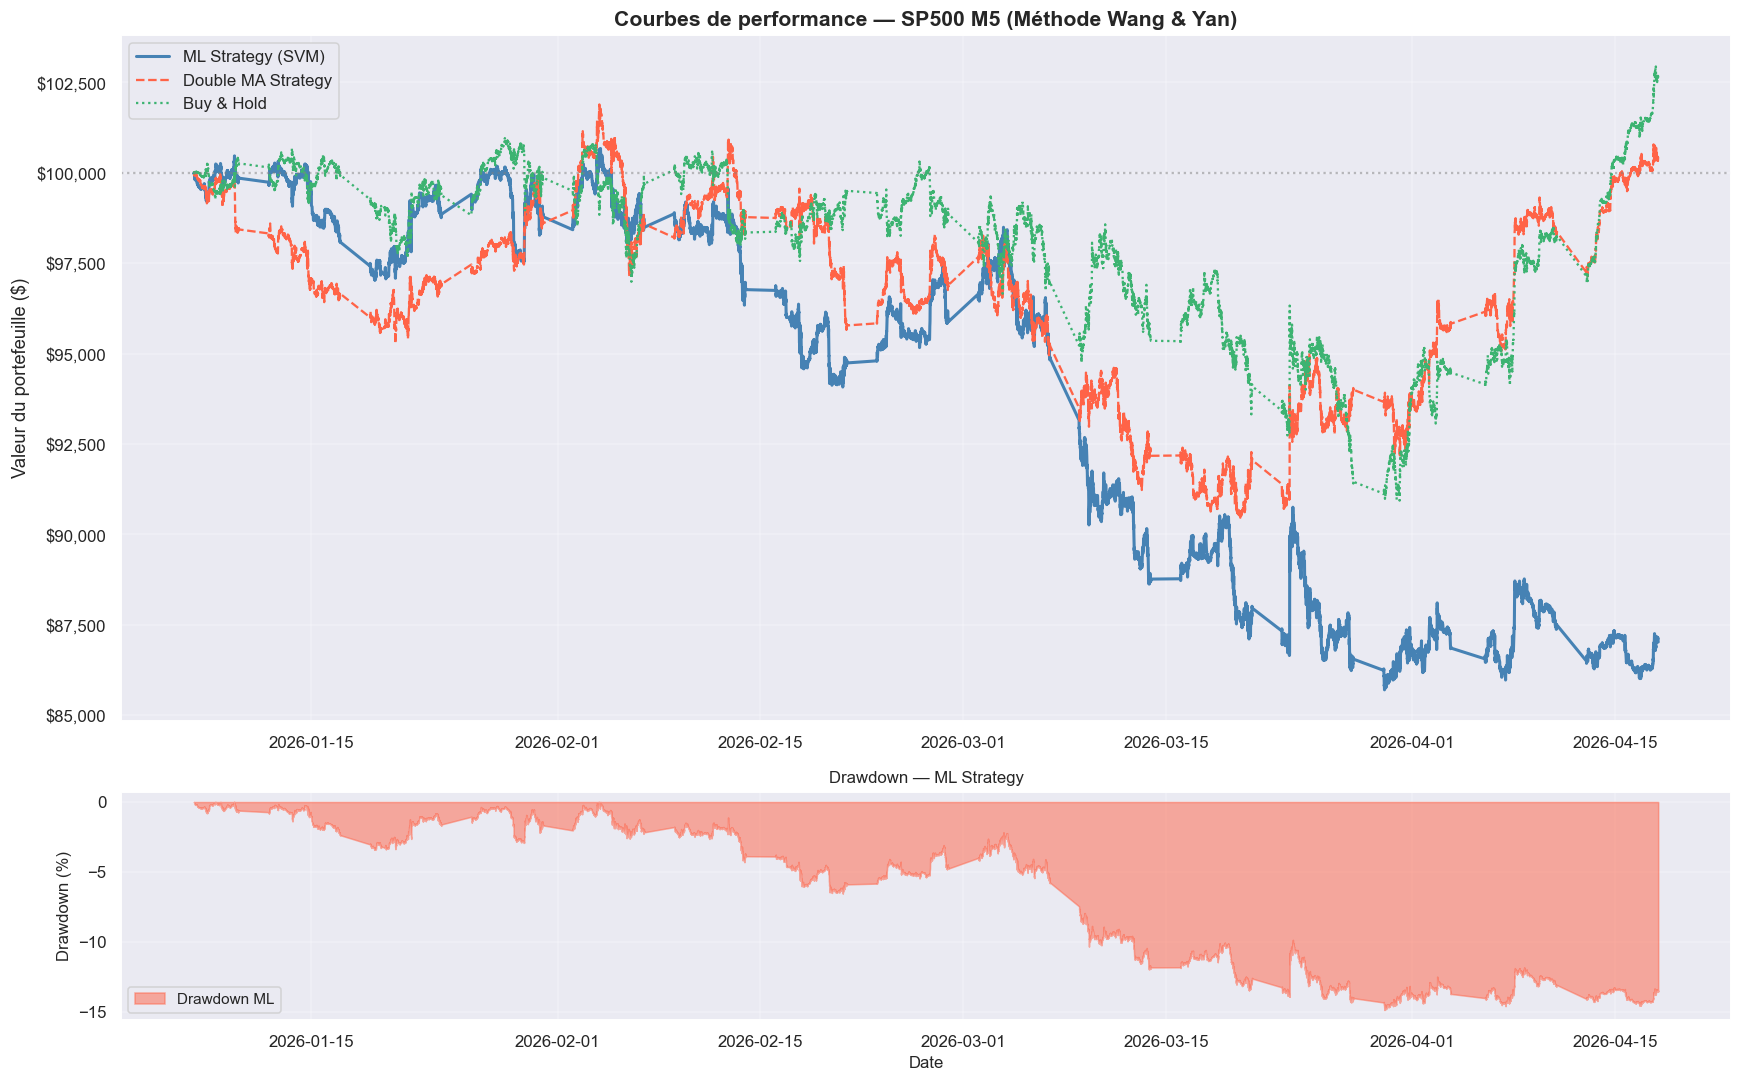

In [18]:
# ── Graphique des equity curves ───────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

# Equity curves
axes[0].plot(test_sim.index, test_sim['equity_ml'],  label=f'ML Strategy ({best_name})', color='steelblue',    linewidth=2)
axes[0].plot(test_sim.index, test_sim['equity_dma'], label='Double MA Strategy',         color='tomato',       linewidth=1.5, linestyle='--')
axes[0].plot(test_sim.index, test_sim['equity_bh'],  label='Buy & Hold',                 color='mediumseagreen', linewidth=1.5, linestyle=':')
axes[0].axhline(CAPITAL_INIT, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title('Courbes de performance — SP500 M5 (Méthode Wang & Yan)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valeur du portefeuille ($)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# Drawdown de la stratégie ML
peak   = test_sim['equity_ml'].cummax()
dd_ml  = (test_sim['equity_ml'] - peak) / peak * 100
axes[1].fill_between(test_sim.index, dd_ml, 0, color='tomato', alpha=0.5, label='Drawdown ML')
axes[1].set_title('Drawdown — ML Strategy', fontsize=11)
axes[1].set_ylabel('Drawdown (%)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/trading_simulation.png', dpi=120, bbox_inches='tight')
plt.show()

# Résumé final
print('\n' + '='*55)
print('  RÉSUMÉ FINAL')
print('='*55)
print(f'  Meilleur modèle ML     : {best_name}')
print(f'  Accuracy classification : {clf_reg_df.loc[clf_reg_df["Modèle"]==best_name, "Accuracy"].values[0]:.3f}')
print(f'  Capital final ML        : ${metrics_ml["Capital final ($)"] :,.0f}')
print(f'  Capital final DMA       : ${metrics_dma["Capital final ($)"] :,.0f}')
print(f'  Rendement annualisé ML  : {metrics_ml["Rendement annualisé (%)"]:.2f}%')
print(f'  Rendement annualisé DMA : {metrics_dma["Rendement annualisé (%)"]:.2f}%')
print('='*55)

## 12. Résumé & Conclusions

### Ce qu'on a reproduit :
| Étape | Article (Bitcoin daily) | Notre version (SP500 M5) |
|-------|------------------------|-------------------------|
| Variable cible | ΔMA5 journalier | ΔMA5 sur bougies M5 |
| Modèles | DT, SVM, RF, Bagging, AdaBoost | Identiques |
| Méthode | Régression → Label binaire | Identique |
| Évaluation | R², MSE, RMSE, MAE | Identique |
| Classification | Accuracy, Precision, Recall, F1 | Identique |
| Simulation | DMA vs ML Strategy | Identique |

### Points clés :
- La méthode **Régression→Label** devrait surpasser la classification directe (comme dans le notebook 02)
- Le **SVM linéaire** était le meilleur modèle dans l'article (accuracy 0.81)
- Sur M5, les résultats peuvent différer car les marchés M5 ont plus de bruit

### Pistes d'amélioration :
- Ajouter des features inter-marchés (Gold, Brent, EURUSD) comme dans le notebook 02
- Tester des paramètres différents pour MA (MA5/MA10 plutôt que MA5/MA20)
- Appliquer un filtre de session (ne trader que pendant les heures US)
- Intégrer un stop-loss dans la simulation